## 디지털 신호 처리 과제 #4
### 201910936 김연수

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date, timedelta

plt.rcParams['figure.figsize'] = (8, 5)

btc = yf.download('BTC-USD', start='2022-01-01', end='2023-01-01')
btc.to_csv('data.csv')

[*********************100%***********************]  1 of 1 completed


In [2]:
if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = btc.columns.get_level_values(0)

btc = btc.reset_index()

# indexing columns as Date
if btc.columns[0] != 'Date':
    btc = btc.rename(columns={btc.columns[0]: 'Date'})

btc.to_csv('data.csv', index=False)

df = pd.read_csv('data.csv', parse_dates=['Date'])


In [3]:
price = df['Close'].dropna().to_numpy(dtype=float)

# Remove the mean before FFT
x = price - price.mean()
N = len(x)
dt = 1.0 # Sample as Daily

freq = np.fft.rfftfreq(N, d=dt)
fft_vals = np.fft.rfft(x)
power = np.abs(fft_vals) ** 2

# Ignore Zero Frequency
mask = freq > 0
freq = freq[mask]
power = power[mask]

# Fit spectral slope on a log-log scale over a reasonable frequency band
fit_mask = (freq >= 2 / N) & (freq <= 0.05)
slope, intercept = np.polyfit(np.log10(freq[fit_mask]), np.log10(power[fit_mask]), 1)

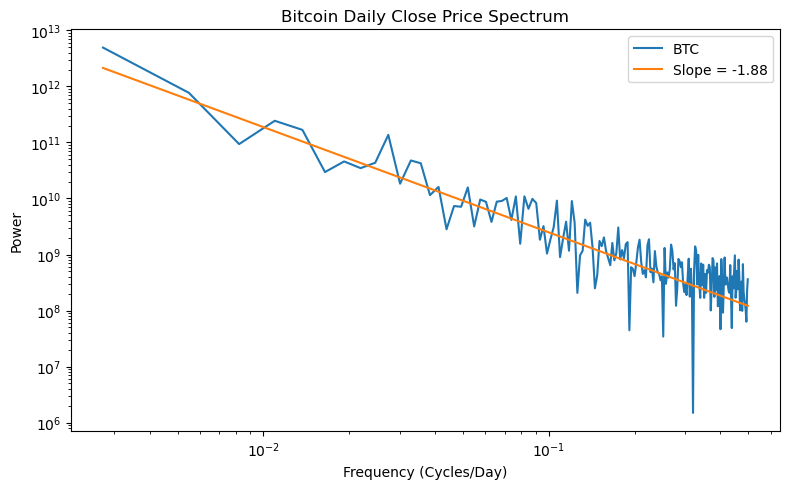

In [10]:
fit_line = 10 ** intercept * freq ** slope

plt.loglog(freq, power, label='BTC')
plt.loglog(freq, fit_line, label=f'Slope = {slope:.2f}')

plt.xlabel('Frequency (Cycles/Day)')
plt.ylabel('Power')
plt.title('Bitcoin Daily Close Price Spectrum')

plt.legend()
plt.tight_layout()
plt.show()


### 해석

- White Noise : 0 근처 Slope
- Pink Noise : -1 근처 Slope
- Brownian Noise : -2 근처 Slope

위 그래프는 Slope 값이 -1.8 근처 Slope로 Brownian Noise에 가깝다.
